# MAAI Bootcamp :: Activity: Evaluating ML models

## Introduction

In this notebook, we will analyze the Adult Census Income dataset, also known as the "Census Income" dataset. The dataset contains information about individuals and whether they earn more than $50,000 a year.

The main goals of this exercise is
* Explore different quality metrics 
* Optimise ML models based on these metrics

The content follows the ML steps presented in the previous section:

1. Look at the big picture
2. Get the data
3. Explore and visualise the data to gain insights
4. Prepare the data for machine learning algorithms
5. Select a model and train it
6. Fine-tune your model
7. Present your solution
8. Launch, monitor, and maintain your system


## 1. Look at the big picture

In this exercise, you'll work with the [Adult Census Income dataset](https://archive.ics.uci.edu/ml/datasets/Census+Income), which is commonly used in machine learning literature. This data was extracted from the [1994 Census bureau database](http://www.census.gov/en.html) by Ronny Kohavi and Barry Becker.

Each example in the dataset contains the following demographic data for a set of individuals who took part in the 1994 Census:

### Numeric Features
*   `age`: The age of the individual in years.
*   `fnlwgt`: an estimate of the number of individuals in the population with the same demographics as this individual
*   `education_num`:  An enumeration of the categorical representation of education. The higher the number, the higher the education that individual achieved. For example, an `education_num` of `11` represents `Assoc_voc` (associate degree at a vocational school), an `education_num` of `13` represents `Bachelors`, and an `education_num` of `9` represents `HS-grad` (high school graduate).
*   `capital_gain`: Capital gain made by the individual, represented in US Dollars.
*   `capital_loss`: Capital loss made by the individual, represented in US Dollars.
*   `hours_per_week`: Hours worked per week.

### Categorical Features
*   `workclass`: The individual's type of employer. Examples include: `Private`, `Self-emp-not-inc`, `Self-emp-inc`, `Federal-gov`, `Local-gov`, `State-gov`, `Without-pay`, and `Never-worked`.
*   `education`: The highest level of education achieved for that individual.
*   `marital_status`: Marital status of the individual. Examples include: `Married-civ-spouse`, `Divorced`, `Never-married`, `Separated`, `Widowed`, `Married-spouse-absent`, and `Married-AF-spouse`.
*   `occupation`: The occupation of the individual. Example include: `tech-support`, `Craft-repair`, `Other-service`, `Sales`, `Exec-managerial` and more.
*   `relationship`:  The relationship of each individual in a household. Examples include: `Wife`, `Own-child`, `Husband`, `Not-in-family`, `Other-relative`, and `Unmarried`.
*   `gender`:  Gender of the individual available only in binary choices: `Female` or `Male`.
*   `race`: `White`, `Asian-Pac-Islander`, `Amer-Indian-Eskimo`, `Black`, and `Other`.
*   `native_country`: Country of origin of the individual. Examples include: `United-States`, `Cambodia`, `England`, `Puerto-Rico`, `Canada`, `Germany`, `Outlying-US(Guam-USVI-etc)`, `India`, `Japan`, and more.

### Prediction Task
The prediction task is to **determine whether a person makes over $50,000 US Dollar a year.**

### Label
*   `income_bracket`: Whether the person makes more than $50,000 US Dollars annually.

### Notes on Data Collection

All the examples extracted for this dataset meet the following conditions:
*   `age` is 16 years or older.
*   The adjusted gross income (used to calculate `income_bracket`) is greater than $100 USD annually.
*   `fnlwgt` is greater than 0.
*   `hours_per_week` is greater than 0.

(source: [[1]](https://developers.google.com/machine-learning/crash-course/fairness))

Your task:
- Determine which learning technique your are using
- Determine which performance measures can be used to assess your models.

## 2. Get the data

### Setup

We'll import the necessary modules to run the code in the rest of this notebook.

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve


### Downloading data

In [145]:
COLUMNS = ["age", "workclass", "fnlwgt", "education", "education_num",
           "marital_status", "occupation", "relationship", "race", "gender",
           "capital_gain", "capital_loss", "hours_per_week", "native_country",
           "income_bracket"]

train_csv = 'task_ds/adult_train.csv'
test_csv = 'task_ds/adult_test.csv'

train_df = pd.read_csv(train_csv, names=COLUMNS, sep=r'\s*,\s*',
                       engine='python', na_values="?")
test_df = pd.read_csv(test_csv, names=COLUMNS, sep=r'\s*,\s*', skiprows=[0],
                      engine='python', na_values="?")

# Strip trailing periods mistakenly included only in UCI test dataset.
test_df['income_bracket'] = test_df.income_bracket.str.rstrip('.')

In [146]:
train_df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,gender,capital_gain,capital_loss,hours_per_week,native_country,income_bracket
0,age,workclass,NaN,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
1,39,State-gov,77516.0,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311.0,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646.0,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721.0,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32557,27,Private,257302.0,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374.0,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910.0,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490.0,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## 3. Explore and visualise the data to gain insights

It is important to understand your dataset *before* diving straight into the prediction task. 

Some examples questions to investigate when auditing a dataset:

* Are there missing feature values for a large number of observations?
* Are there features that are missing that might affect other features?
* Are there any unexpected feature values?
* What signs of data skew do you see?

## Check null and nAn values

In [147]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32562 entries, 0 to 32561
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32562 non-null  object 
 1   workclass       30726 non-null  object 
 2   fnlwgt          32561 non-null  float64
 3   education       32562 non-null  object 
 4   education_num   32562 non-null  object 
 5   marital_status  32562 non-null  object 
 6   occupation      30719 non-null  object 
 7   relationship    32562 non-null  object 
 8   race            32562 non-null  object 
 9   gender          32562 non-null  object 
 10  capital_gain    32562 non-null  object 
 11  capital_loss    32562 non-null  object 
 12  hours_per_week  32562 non-null  object 
 13  native_country  31979 non-null  object 
 14  income_bracket  32562 non-null  object 
dtypes: float64(1), object(14)
memory usage: 3.7+ MB


In [148]:
# Columns to check for NaN values
columns_to_check = ['education_num', 'age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']

# Check for NaN values in the specified columns
nan_rows = train_df[train_df[columns_to_check].isnull().any(axis=1)]

# Display rows with NaN values
print("Rows with NaN values in the specified columns:")
print(nan_rows)

# Display the count of NaN values for each column
nan_counts = train_df[columns_to_check].isnull().sum()
print("\nCount of NaN values per column:")
print(nan_counts)

Rows with NaN values in the specified columns:
   age  workclass  fnlwgt  education  education_num  marital_status  \
0  age  workclass     NaN  education  education-num  marital-status   

   occupation  relationship  race gender  capital_gain  capital_loss  \
0  occupation  relationship  race    sex  capital-gain  capital-loss   

   hours_per_week  native_country income_bracket  
0  hours-per-week  native-country         Income  

Count of NaN values per column:
education_num     0
age               0
fnlwgt            1
capital_gain      0
capital_loss      0
hours_per_week    0
dtype: int64


## Force number values to be numerical

In [149]:
numeric_columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
train_df[numeric_columns] = train_df[numeric_columns].apply(pd.to_numeric, errors='coerce')

In [150]:
# Check for missing values in the dataset
missing_values = train_df.isnull().sum()
print("Missing values per feature:\n", missing_values)

# Check the percentage of missing values
missing_percentage = (missing_values / len(train_df)) * 100
print("\nPercentage of missing values per feature:\n", missing_percentage)

Missing values per feature:
 age                  1
workclass         1836
fnlwgt               1
education            0
education_num        1
marital_status       0
occupation        1843
relationship         0
race                 0
gender               0
capital_gain         1
capital_loss         1
hours_per_week       1
native_country     583
income_bracket       0
dtype: int64

Percentage of missing values per feature:
 age               0.003071
workclass         5.638474
fnlwgt            0.003071
education         0.000000
education_num     0.003071
marital_status    0.000000
occupation        5.659972
relationship      0.000000
race              0.000000
gender            0.000000
capital_gain      0.003071
capital_loss      0.003071
hours_per_week    0.003071
native_country    1.790431
income_bracket    0.000000
dtype: float64


Working class and occupation are missing a lot. It's good to check if those happen to be mostly missing together because that would make the data better for removal because it would be hard to figure out what it would have been.

In [151]:
# Count rows where both 'workclass' and 'occupation' are missing
both_missing = train_df[train_df['workclass'].isnull() & train_df['occupation'].isnull()]
print(f"Number of rows where both 'workclass' and 'occupation' are missing: {len(both_missing)}")

Number of rows where both 'workclass' and 'occupation' are missing: 1836


It seems that the cases where this is missing it's both at once. So it makes most sense to drop these rows. Native country can be added as unknown for now.

In [152]:
# Drop rows where 'workclass' or 'occupation' is missing
train_df = train_df.dropna(subset=['workclass', 'occupation'])

# Set missing values in 'native_country' to 'Unknown' using .loc
train_df.loc[:, 'native_country'] = train_df['native_country'].fillna('Unknown')

In [153]:
# missing_values = train_df.isnull().sum()
# print("Missing values per feature:\n", missing_values)

# missing_percentage = (missing_values / len(train_df)) * 100
# print("\nPercentage of missing values per feature:\n", missing_percentage)

## Check for unexpected feature values

In [154]:
# Categorical features
categorical_columns = ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'gender', 'native_country']
for col in categorical_columns:
    print(f"Value counts for {col}:\n", train_df[col].value_counts(), "\n")


Value counts for workclass:
 workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
workclass               1
Name: count, dtype: int64 

Value counts for education:
 education
HS-grad         9968
Some-college    6775
Bachelors       5182
Masters         1675
Assoc-voc       1321
11th            1056
Assoc-acdm      1020
10th             831
7th-8th          573
Prof-school      558
9th              463
Doctorate        398
12th             393
5th-6th          303
1st-4th          156
Preschool         46
education          1
Name: count, dtype: int64 

Value counts for marital_status:
 marital_status
Married-civ-spouse       14339
Never-married             9912
Divorced                  4258
Separated                  959
Widowed                    840
Married-spouse-absent      389
Married-AF-spouse           21
marital-status               1
Name

Most features have their own name appear once as a value which is an error so those should be dropped. For simplicity this can be done by dropping the value counts that are only 1.

In [155]:
for col in categorical_columns:
    value_counts = train_df[col].value_counts()
    train_df = train_df[~train_df[col].isin(value_counts[value_counts == 1].index)]

# for col in categorical_columns:
#     print(f"Value counts for {col} after filtering:\n", train_df[col].value_counts(), "\n")

## Data distribution and skew

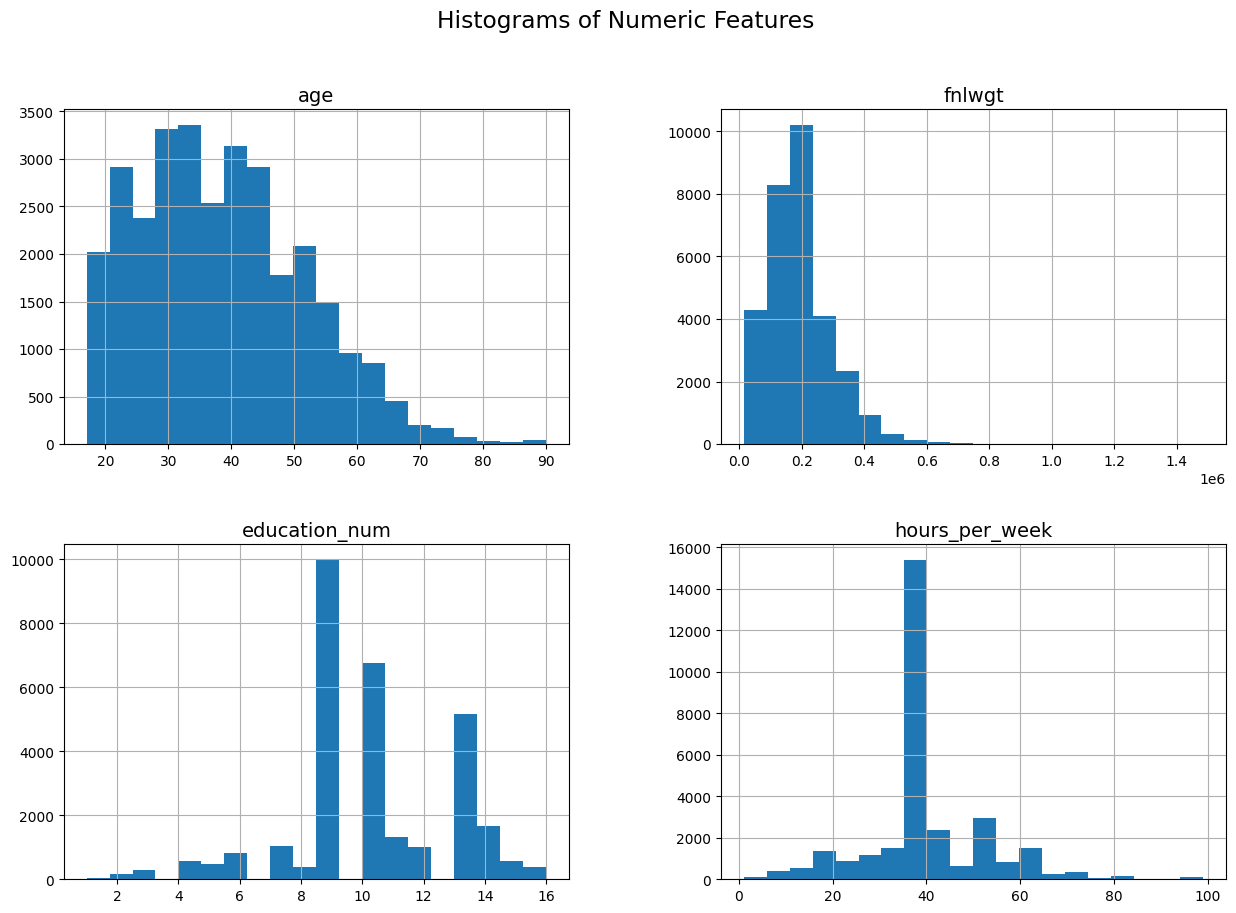

In [ ]:
# Plot histograms again
train_df[numeric_columns].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Numeric Features")
plt.show()

THe capital gain and loss are mostly null values, options are to set it to a binary value if capital losses and gains were registered. Or remove the feature. Trying to turn it into one feature net capital by substracting gain and loss still left 0 dominant.

In [157]:
# Drop the 'capital_gain' and 'capital_loss' columns
train_df = train_df.drop(columns=['capital_gain', 'capital_loss'])

# Verify the columns have been removed
print("Remaining columns:\n", train_df.columns)

Remaining columns:
 Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'gender',
       'hours_per_week', 'native_country', 'income_bracket'],
      dtype='object')


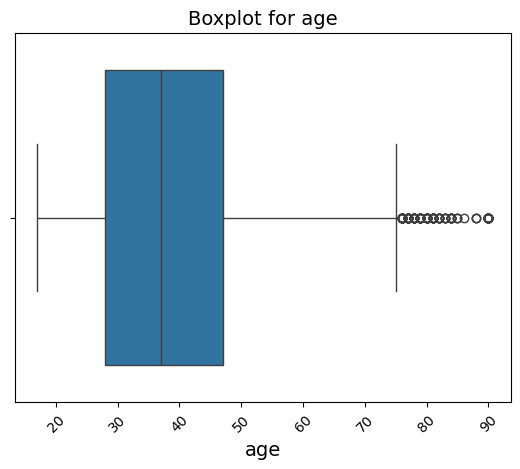

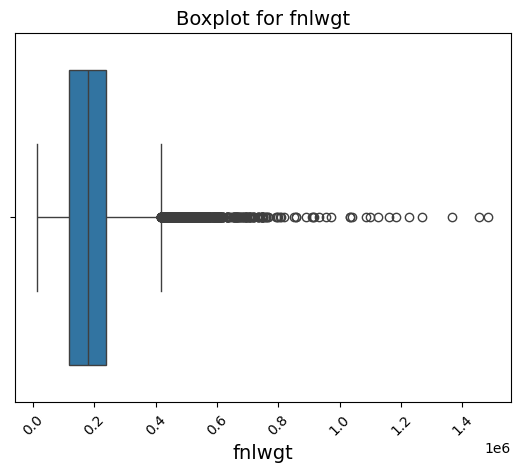

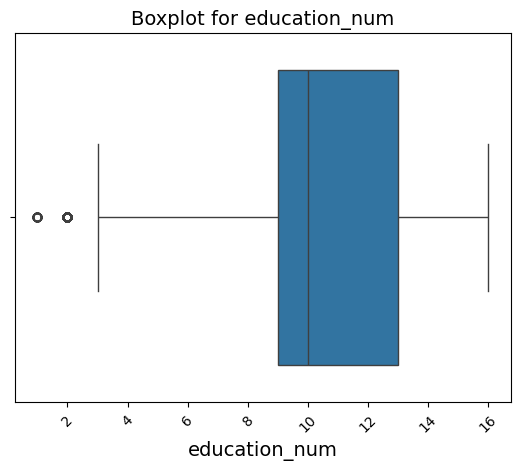

KeyError: 'capital_gain'

In [159]:
# Boxplots for numeric features
for col in numeric_columns:
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot for {col}")
    plt.xticks(rotation=45)  # Rotate x-axis labels
    plt.show()

# Distribution plots
for col in numeric_columns:
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)  # Rotate x-axis labels
    plt.show()

## Correlation matrix

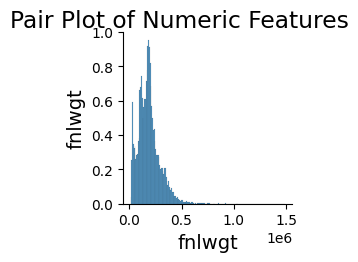

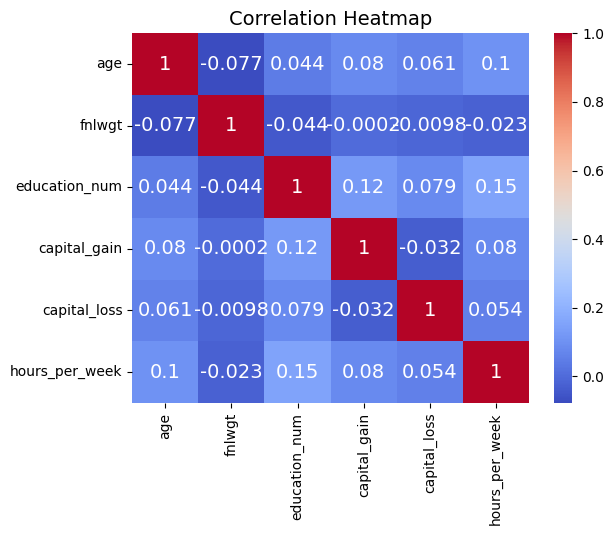

In [ ]:
# Pair plot for numeric features
sns.pairplot(train_df[numeric_columns])
plt.suptitle("Pair Plot of Numeric Features", y=1.02)
plt.show()

# Correlation heatmap
correlation_matrix = train_df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Distribution of target variable

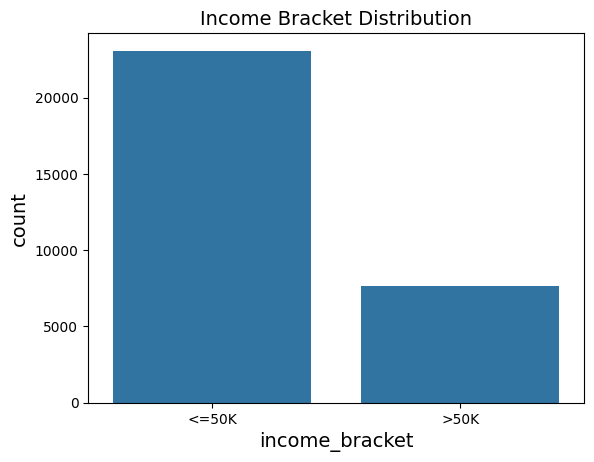

In [ ]:
sns.countplot(x='income_bracket', data=train_df)
plt.title("Income Bracket Distribution")
plt.show()

## TODO: scatter matrix

Make a notebook template with steps, which options for models and data sanization and a guide and places for notes


## 4. Prepare the data for machine learning algorithms

Here you should perform data cleaning and transformations. Examples are removing or replacing missing values, turning categorical features into one-hot encoding representations.

## 5. Select a model and train it

We suggest you select two or more algorithms (e.g. KNN, Decision Trees, Random Forest).


## 6. Optional: Fine-tune your model

Get the optimal hyperparameter configuration for each chosen algorithm. 

Only in the end, you should use test data to collect metrics

## 7. Present your solution

Here you should summarise your findings

## 8. Launch, monitor, and maintain your system

Out of the scope for this exercise.

## 9. Reflect on the what you did

Take some time, reflecting on what you did and how you have peformed. Use the the following learning outcomes of the Master of Applied AI as a basis:

B3: Je ontwikkelt een nieuw of voorgetraind AI-model volgens een iteratief en systematisch proces.

C2: Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden zoals robustness, performance, scalability, explainability, model complexity en resource demand.

D1: Je verzamelt en verwerkt actief feedback over de eigen kennis, vaardigheden en ontwikkeling en laat zien deze feedback te kunnen gebruiken om je werk te verbeteren.